In [1]:
import numpy as np, pandas as pd, torch, sys
sys.path.append("../")
from ad_utils import *

device = torch.device("cuda:1")
print(torch.cuda.get_device_name(device) if torch.cuda.is_available() else "No GPU available")

train = np.load('npy/train_FD001.npy') # the data is normalized with Z-Scale
test = np.load('npy/test_FD001.npy')
print(train.shape, test.shape)

NVIDIA A30
(200, 30, 19) (188, 30, 19)


# Create test label, and randomized permutation.

In [2]:
norm_label = torch.zeros(100)
fault_label = torch.ones(88)
test_label = torch.cat([norm_label, fault_label])
perm = torch.randperm(len(test))

# Convert to images

In [3]:
train_img = build_image_tensor(train, device)
test_img = build_image_tensor(test, device)
print("Train Img min-max values: ", train_img.min(), train_img.max())
print("Test Img min-max values: ", test_img.min(), test_img.max())

print("Train img shape: ", train_img.shape)
print("Test img shape: ", test_img.shape)
torch.cuda.empty_cache()

Train Img min-max values:  tensor(0., device='cuda:1') tensor(1., device='cuda:1')
Test Img min-max values:  tensor(0., device='cuda:1') tensor(1., device='cuda:1')
Train img shape:  torch.Size([200, 19, 3, 224, 224])
Test img shape:  torch.Size([188, 19, 3, 224, 224])


# Extract Feature

In [4]:
train_feat = extract_features(train_img, device)
test_feat = extract_features(test_img, device)
print(train_feat.shape, test_feat.shape)

torch.Size([200, 77824]) torch.Size([188, 77824])


# Model initation and train

In [5]:
model = Autoencoder(n_sensors=train.shape[-1])
normalizer = FeatureNormalizer()
hist, normalizer = train_autoencoder(model=model, features_data=train_feat, device=device, normalizer=normalizer, lr=0.0001, n_epochs=50)
torch.cuda.empty_cache()


  Training AE  (200 samples, 50 epochs)
Epoch    1/50  Loss: 0.158369
Epoch    2/50  Loss: 0.149056
Epoch    3/50  Loss: 0.044096
Epoch    4/50  Loss: 0.032305
Epoch    5/50  Loss: 0.026912
Epoch    6/50  Loss: 0.024432
Epoch    7/50  Loss: 0.023507
Epoch    8/50  Loss: 0.022967
Epoch    9/50  Loss: 0.022786
Epoch   10/50  Loss: 0.022665
Epoch   11/50  Loss: 0.022558
Epoch   12/50  Loss: 0.022488
Epoch   13/50  Loss: 0.022476
Epoch   14/50  Loss: 0.022415
Epoch   15/50  Loss: 0.022462
Epoch   16/50  Loss: 0.022402
Epoch   17/50  Loss: 0.022367
Epoch   18/50  Loss: 0.022415
Epoch   19/50  Loss: 0.022408
Epoch   20/50  Loss: 0.022436
Epoch   21/50  Loss: 0.022486
Epoch   22/50  Loss: 0.022533
Epoch   23/50  Loss: 0.022489
Epoch   24/50  Loss: 0.022527
Epoch   25/50  Loss: 0.022532
Epoch   26/50  Loss: 0.022494
Epoch   27/50  Loss: 0.022510
Epoch   28/50  Loss: 0.022558
Epoch   29/50  Loss: 0.022609
Epoch   30/50  Loss: 0.022591
Epoch   31/50  Loss: 0.022591
Epoch   32/50  Loss: 0.022623

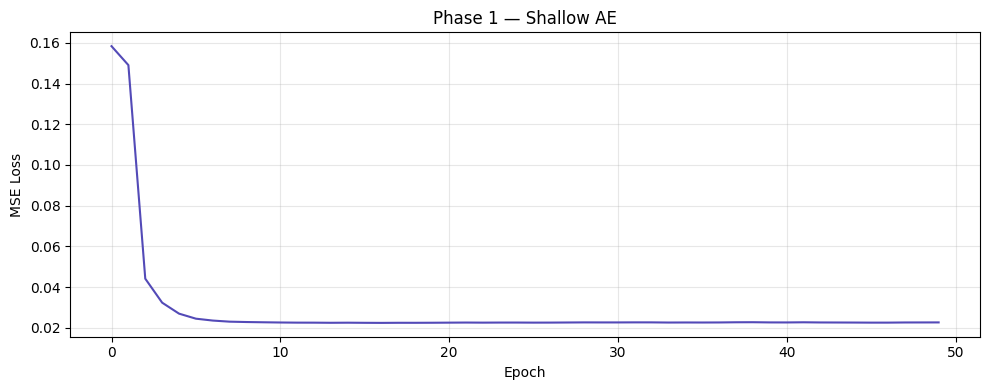

In [6]:
plot_training_curve(hist)

# Randomize test 

In [7]:
train_error = reconstruction_error(model=model, features_raw=train_feat, N_SENSORS=19, normalizer=normalizer, device=device, agg="mean")
test_error  = reconstruction_error(model=model, features_raw=test_feat, N_SENSORS=19, normalizer=normalizer, device=device, agg="mean")

[[97  3]
 [57 31]]

────────────────────────────────────────────────────
  Evaluation
────────────────────────────────────────────────────
  precision    0.9118
  recall       0.3523
  accuracy     0.6809
  f1           0.5082
  auc          0.4953


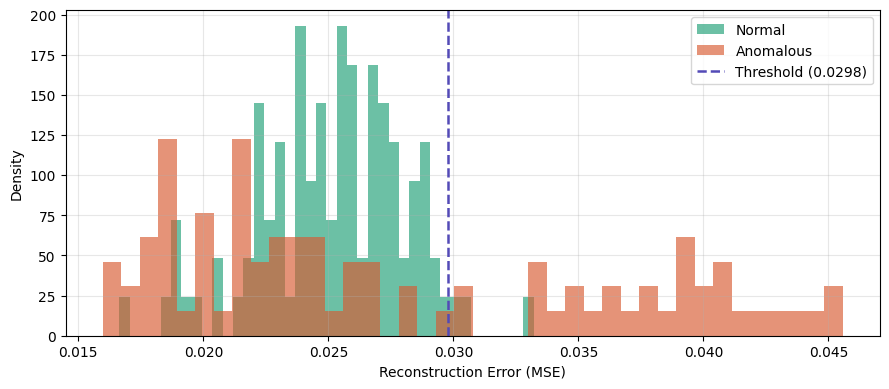

In [15]:
thresh = np.percentile(train_error, 95.5)
compute_metrics(errors=test_error, true_labels=test_label, threshold=thresh)
plot_error_distributions(test_error, test_label, thresh, title="")
